In [37]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from typing import Optional
import random
import numpy as np
import torch
from sklearn.decomposition import TruncatedSVD
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm

from vrAnalysis.helpers import Timer, format_spines, beeswarm, errorPlot, save_figure
from dimilibi import PCA, SVCA


from dimensionality_manuscript.simulations import (
    CovarianceGenerator,
    PowerlawDataGenerator, 
    RotatedEigenbasisGenerator,
    geometric_mean_spd, 
    root_sandwich,
    plot_ellipse, 
    get_orthogonal_direction, 
    generate_orthonormal,
    sqrtm_spd,
    SharedSpaceConfig,
    SharedSpaceGenerator,
    find_commute_space,
    find_commute_space_gated,
)

plt.rcParams["font.size"] = 14

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


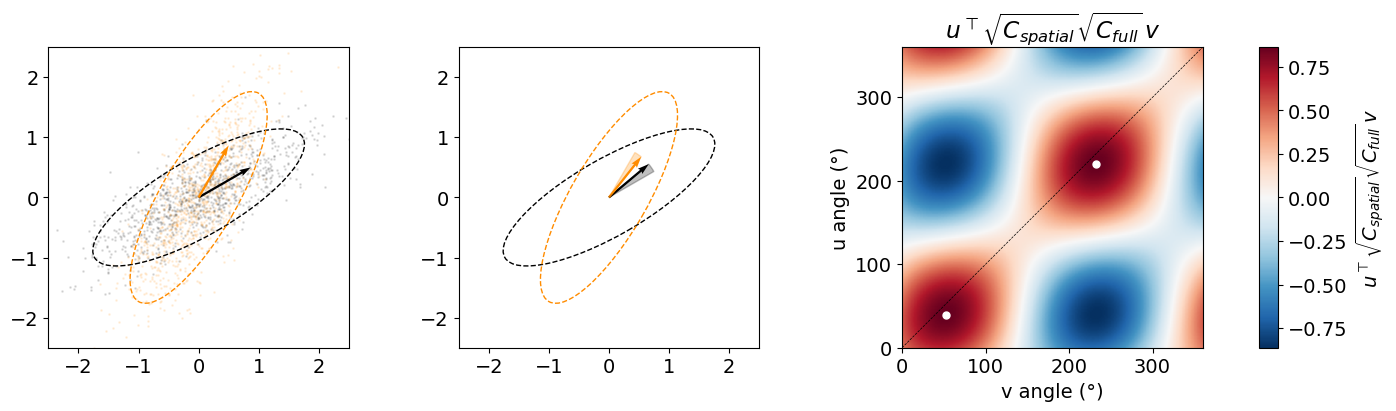

In [12]:
# Build a 2D simulation demonstration
def get_rotation(angle_degrees: float) -> np.ndarray:
    angle_radians = np.deg2rad(angle_degrees)
    rotation_matrix = np.array([[np.cos(angle_radians), -np.sin(angle_radians)], [np.sin(angle_radians), np.cos(angle_radians)]])
    return rotation_matrix


def normalize(array: np.ndarray, axis: int = None) -> np.ndarray:
    return array / np.linalg.norm(array, axis=axis, keepdims=True)


def get_orthogonal(vector: np.ndarray) -> np.ndarray:
    if vector.shape[0] != 2:
        raise ValueError("Input vector must be 2D")
    return np.array([-vector[1], vector[0]])


from matplotlib.patches import Ellipse
from matplotlib.patches import Wedge


def plot_ellipse(ax, mean, eigvecs, eigvals, n_std=2, **kwargs):
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)


rotation_offset = 15  # degrees from 45 --- can't be more than 45 or less than 0
if rotation_offset > 45 or rotation_offset < 0:
    raise ValueError("rotation_offset must be between 0 and 45 degrees")

a_from_0 = 45 - rotation_offset
b_from_0 = 45 + rotation_offset
a1 = normalize(get_rotation(a_from_0) @ np.array([1, 0]))
b1 = normalize(get_rotation(b_from_0) @ np.array([1, 0]))
a2 = normalize(get_orthogonal(a1))
b2 = normalize(get_orthogonal(b1))
lam = np.array([1.0, 0.1])
cov_a = a1[:, None] * a1[None, :] * lam[0] + a2[:, None] * a2[None, :] * lam[1]
cov_b = b1[:, None] * b1[None, :] * lam[0] + b2[:, None] * b2[None, :] * lam[1]

data_a = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_a, size=1000)
data_b = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_b, size=1000)

A = np.cov(data_a.T)
B = np.cov(data_b.T)
rA = sqrtm_spd(A)
rB = sqrtm_spd(B)
rAtrue = sqrtm_spd(cov_a)
rBtrue = sqrtm_spd(cov_b)
Ur_true, svals_true, Vt_true = np.linalg.svd(rAtrue @ rBtrue)
Uroot, svals_xyroot, Vtroot = np.linalg.svd(rA @ rB)


if np.all(Uroot[:, 0] < 0):
    Uroot[:, 0] *= -1
    Vtroot[:, 0] *= -1


# I want to measure the product u @ rA @ rB @ vT for all combinations of u, vT around the unit circle given a number of samples.
n_samples = 200
angles = np.linspace(0, 2 * np.pi, n_samples, endpoint=False)
angles_in_degrees = np.degrees(angles)
u_circle = np.column_stack([np.cos(angles), np.sin(angles)])  # (n_samples, 2)
rArB = rA @ rB
heatmap = u_circle @ rArB @ u_circle.T  # (n_samples, n_samples)
idx_y, idx_x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
best_y = angles_in_degrees[idx_y]
best_x = angles_in_degrees[idx_x]

color_a = "black"
color_b = "darkorange"

plt.close("all")
fig, ax = plt.subplots(1, 4, figsize=(14, 4), width_ratios=[1, 1, 1, 0.05], layout="constrained")
ax[1].sharex(ax[0])
ax[1].sharey(ax[0])
ax[0].scatter(data_a[:, 0], data_a[:, 1], color=color_a, alpha=0.1, s=1)
ax[0].scatter(data_b[:, 0], data_b[:, 1], color=color_b, alpha=0.1, s=1)
plot_ellipse(ax[0], mean=np.zeros(2), eigvecs=np.column_stack((a1, a2)), eigvals=lam, edgecolor=color_a, facecolor="none", linestyle="--", n_std=2.0)
plot_ellipse(ax[0], mean=np.zeros(2), eigvecs=np.column_stack((b1, b2)), eigvals=lam, edgecolor=color_b, facecolor="none", linestyle="--", n_std=2.0)
ax[0].quiver(0, 0, a1[0] * lam[0], a1[1] * lam[0], angles="xy", scale_units="xy", scale=1, color=color_a, label='"Full PC1"')
ax[0].quiver(0, 0, b1[0] * lam[0], b1[1] * lam[0], angles="xy", scale_units="xy", scale=1, color=color_b, label='"Spatial PC1"')
# ax[0].legend(loc="lower left", fontsize=12)
ax[0].set_aspect("equal")

plot_ellipse(ax[1], mean=np.zeros(2), eigvecs=np.column_stack((a1, a2)), eigvals=lam, edgecolor=color_a, facecolor="none", linestyle="--", n_std=2.0)
plot_ellipse(ax[1], mean=np.zeros(2), eigvecs=np.column_stack((b1, b2)), eigvals=lam, edgecolor=color_b, facecolor="none", linestyle="--", n_std=2.0)
ax[1].quiver(
    0,
    0,
    Uroot[0, 0] * svals_xyroot[0],
    Uroot[1, 0] * svals_xyroot[0],
    angles="xy",
    scale_units="xy",
    scale=1,
    color=color_a,
    label="Uroot1",
)
ax[1].quiver(
    0,
    0,
    Vtroot[0, 0] * svals_xyroot[0],
    Vtroot[1, 0] * svals_xyroot[0],
    angles="xy",
    scale_units="xy",
    scale=1,
    color=color_b,
    label="Vtroot1",
)
angle_a1 = np.degrees(np.arctan2(a1[1], a1[0]))
angle_u = np.degrees(np.arctan2(Uroot[1, 0], Uroot[0, 0]))
angle_b1 = np.degrees(np.arctan2(b1[1], b1[0]))
angle_v = np.degrees(np.arctan2(Vtroot[1, 0], Vtroot[0, 0]))
ax[1].add_patch(Wedge((0, 0), svals_xyroot[0], min(angle_a1, angle_u), max(angle_a1, angle_u), color=color_a, alpha=0.25, label="u offset"))
ax[1].add_patch(Wedge((0, 0), svals_xyroot[0], min(angle_b1, angle_v), max(angle_b1, angle_v), color=color_b, alpha=0.25, label="v offset"))
ax[1].set_xlim(-2.5, 2.5)
ax[1].set_ylim(-2.5, 2.5)
ax[1].set_aspect("equal")

degrees = 360
im = ax[2].imshow(heatmap, extent=[0, degrees, 0, degrees], origin="lower", aspect="auto", cmap="RdBu_r")
ax[2].plot([0, degrees], [0, degrees], color="k", linestyle="--", linewidth=0.5)
ax[2].plot([best_x], [best_y], "wo", markersize=5, label=f"Best: ({best_x:.1f}°, {best_y:.1f}°)")
ax[2].plot([(best_x + 180) % 360], [(best_y + 180) % 360], "wo", markersize=5, label=f"Best: ({best_x:.1f}°, {best_y:.1f}°)")
ax[2].set_xlabel("v angle (°)")
ax[2].set_ylabel("u angle (°)")
ax[2].set_title(r"$u^\top \sqrt{C_{spatial}}\sqrt{C_{full}}\, v$")
ax[2].set_aspect("equal")
plt.colorbar(im, cax=ax[3], label=r"$u^\top \sqrt{C_{spatial}}\sqrt{C_{full}}\, v$")

plt.show()

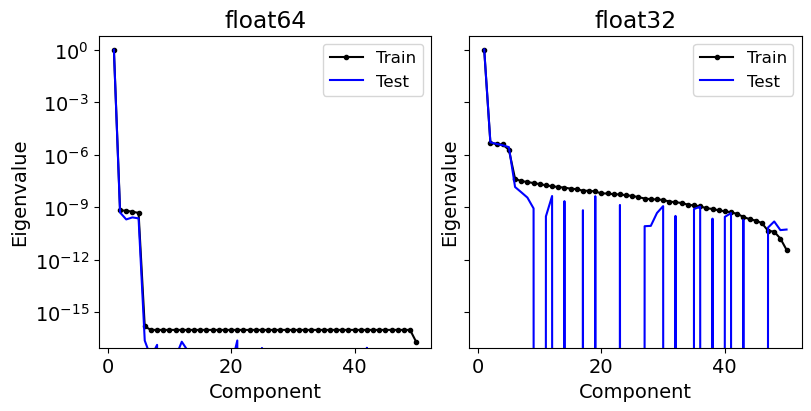

In [ ]:
values = "user"

alpha_shared_1 = 0.0
alpha_shared_2 = 0.0
alpha_private_1 = 0.0
alpha_private_2 = 0.0
shuffle_shared = False
private_ratio = 0.1
S = 1000
noise_variance = 0.0
rotation_angle = 0


num_neurons = 50
shared_dimensions = 1
private_dimensions = (2, 2)
cfg = SharedSpaceConfig(
    num_neurons=num_neurons,
    shared_dimensions=shared_dimensions,
    private_dimensions=private_dimensions,
    alpha_shared_1=alpha_shared_1,
    alpha_shared_2=alpha_shared_2,
    shuffle_shared=shuffle_shared,
    alpha_private_1=alpha_private_1,
    alpha_private_2=alpha_private_2,
    private_ratio=private_ratio,
)


plt.close("all")
fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="constrained", sharex=True, sharey=True)


for i, dtype in enumerate([np.float64, np.float32]):
    generator = SharedSpaceGenerator(cfg, dtype=dtype)
    data1, data2 = generator.generate(S, noise_variance=noise_variance)
    test1, test2, extras = generator.generate(S, noise_variance=noise_variance, rotation_angle=rotation_angle, return_extras=True)

    Atrue, Btrue = generator.true_covariance()
    rAtrue = sqrtm_spd(Atrue)
    rBtrue = sqrtm_spd(Btrue)
    A = np.cov(data1, dtype=dtype)
    B = np.cov(data2, dtype=dtype)
    rA = sqrtm_spd(A)
    rB = sqrtm_spd(B)

    # Measure on training data
    svals_true = np.linalg.svd(rAtrue @ rBtrue)[1]
    Uroot, svals_xyroot, Vtroot = np.linalg.svd(rA @ rB)

    # Measure on test data
    Atest = np.cov(test1, dtype=dtype)
    Btest = np.cov(test2, dtype=dtype)
    rAtest = sqrtm_spd(Atest)
    rBtest = sqrtm_spd(Btest)
    svals_xy_test = np.diag(Uroot.T @ rAtest @ rBtest @ Vtroot.T)

    xvals = lambda x: range(1, len(x) + 1)
    norm = lambda x: x / np.sum(x)

    # labels = ("S",)
    labels = ("Train", "Test")
    ax[i].plot(xvals(svals_true), svals_true + 0.00, label=labels[0], marker=".", markersize=6, color="k")
    ax[i].plot(xvals(svals_xy_test), svals_xy_test + 0.00, label=labels[1], color="b")
    # ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    ax[i].legend(fontsize=12)
    ax[i].set_xlabel("Component")
    ax[i].set_ylabel("Eigenvalue")
    ax[i].set_title(dtype.__name__)
    ax[i].set_ylim(9.55779680237488e-18, 6.463372002980384)

plt.show()